# Explore Automobile dataset For Beginners 🎉


**<p style="font-size:17px; font-weight:lightbold; font-family: 'Helvetica'">Intro to the dataset and the main problem 😃</p>**


<p style="font-size:16px; font-weight:lighter; font-family: 'Helvetica'; line-height:1.8;">
We can use this dataset for multiple learning purposes 👍<br><br>
Since it offers a good number of columns, it enables us to explore various target classes and tackle prediction, classification, and regression problems.<br><br>
But today we will introduce a new type of problem:<br><br>
<span style="font-weight:bold;">Semi-Supervised Multi-Class Classification!</span>
</p>

<p style="font-size:16px; font-weight:bold; font-family: 'Helvetica';">✔ What is Semi-Supervised?</p>
<p style="font-size:16px; font-weight:lighter; font-family: 'Helvetica'; line-height:1.8;">
- The dataset contains both labeled examples (data with known class labels) and unlabeled examples (data with no class labels).<br><br>
- In other words, in our target class, there will be labeled and unlabeled rows.
</p>

<p style="font-size:16px; font-weight:bold; font-family: 'Helvetica';">✔ What is Multi-Class?</p>
<p style="font-size:16px; font-weight:lighter; font-family: 'Helvetica'; line-height:1.8;">
The goal is to assign one of multiple possible classes (categories) to a given input.
</p>

<p style="font-size:16px; font-weight:bold; font-family: 'Helvetica';">👀 What Models to Involve?</p>
<p style="font-size:16px; font-weight:lighter; font-family: 'Helvetica'; line-height:1.8;">
1) Logistic Regression:<br>
Simple, interpretable model for classification. Good for understanding basic relationships.<br><br>
2) Random Forest (Tree-Based Model):<br>
Handles non-linear relationships and mixed data types well. Robust to missing data and less prone to overfitting.<br><br>
3) SVM:<br>
Performs well with a clear margin of separation in data and uses scaled features.
</p>


<p style="font-size:16px; font-family: 'Helvetica'; line-height:1.8; font-weight:lighter;">
<strong>What is the target class 👀?</strong><br >
The target class is <strong>symboling</strong>.
<br><br>
<strong>What does the symboling class indic ate?</strong><br>
It represents the <strong>Insurance Risk Level</strong>, an integer value in the range [-2, -1, 0, 1, 2, 3].
<br><br>
<strong>What is the real-life problem we are trying to solve?</strong><br>
This risk level helps determine car insurance costs. Insurance companies use this value to decide how much to charge each driver or car based on multiple criteria.
<br><br>
<strong>Example:</strong><br>
Type of Car: Some cars are more expensive to insure because they are more likely to be stolen or cost more to repair. For instance, a sports car will generally have higher insurance premiums than a family sedan.
</p>


<p style="font-size:16px; font-family: 'Helvetica'; line-height:1.8; font-weight:lighter;">
<strong>EDA (Exploratory Data Analysis)</strong>
<br>
1) Load the dataset and inspect its structure.<br>
2) Identify missing data.<br>
3) Visualize the correlation between the numerical features.<br>
4) Explore the distribution of categorical features.<br>
5) Visualize the distribution of target class values.
</p>


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("/kaggle/input/automobile-dataset/Automobile_data.csv")

# Initialize the target class
target = 'symboling'

# Step 1: Inspect the dataset structure
# Dataset Overview: Display first few rows
print("Dataset Overview:")
display(data.head())  # This will nicely show the top rows in Jupyter

display(data.info())

summary_stats = data.describe().transpose()
print(summary_stats)

# Step 2: Identify missing values
print("\nMissing Values:")
missing_values = (data == '?').sum()

#visualize missing values as a bar chart
missing_values = missing_values[missing_values > 0]
# Plot the bar chart using sns
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title('Missing Values by Attribute')
plt.xlabel('Attributes')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Step 3: Visualize the correlation between numerical  
data_cleaned = data.replace('?', np.nan)

numerical_features = data_cleaned.select_dtypes(include=['float64', 'int64']).columns

data_cleaned[numerical_features] = data_cleaned[numerical_features].apply(pd.to_numeric, errors='coerce')

correlation_matrix = data_cleaned[numerical_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Step 4: Visualize some categorical features
categorical_features = data.select_dtypes(include=['object']).columns
for feature in ['make','fuel-type','num-of-doors','body-style']:
    plt.figure()
    # top_values = data[feature].value_counts().nlargest(10).index
    # sns.countplot(data=data[data[feature].isin(top_values)], x=feature, order=top_values)
    sns.countplot(data=data, x=feature, order=data[feature].value_counts().nlargest(10).index)
    plt.title(f"Frequency Distribution of {feature}")
    plt.xticks(rotation=45)
    plt.show()

# Step 5: Check for class balance
if target in data.columns:
    plt.figure()
    sns.countplot(data=data, x=target, order=data[target].value_counts().index)
    plt.title("Class Distribution of Target Variable")
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/automobile-dataset/Automobile_data.csv'

<p style="font-size:16px; font-weight:lightbold; font-family: 'Helvetica'"> 
<strong>Now let's preprocess the dataset: ✌</strong> 
<br> 1) Create a copy of the dataset to preprocess without editing the original.
<br> 2) Handle Missing Values.
<br> 3) Encode Categorical Variables using a one-hot encoder instead of a label encoder, as one-hot encoding is more appropriate for the SVM model we'll use later.
<br> 4) Apply Feature Scaling (excluding the target class).
<br> 5) Perform Feature Standardization.
<br> 6) Split the dataset into training, validation, and testing sets.
<br> 7) Handle Class Imbalance in the target class. </p>


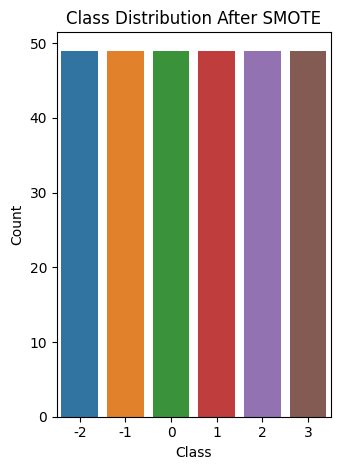

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Copy for preprocessing
processed_data = data.copy()
processed_data.replace('?', np.nan, inplace=True)

# Step 1: Handling Missing Values
# Numerical features - Mean Imputation
missing_numerical_features = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for feature in missing_numerical_features:
    processed_data[feature] = pd.to_numeric(processed_data[feature], errors='coerce')  # Convert to numeric
    processed_data[feature].fillna(processed_data[feature].mean(), inplace=True)

# Categorical features - Mode Imputation
categorical_features = ['num-of-doors']  # Add other categorical features if necessary
for feature in categorical_features:
    processed_data[feature].fillna(processed_data[feature].mode()[0], inplace=True)

# Step 2: Encoding Categorical Variables
categorical_columns = processed_data.select_dtypes(include=['object']).columns
processed_data = pd.get_dummies(processed_data, columns=categorical_columns, drop_first=True)

# Step 3: Feature Scaling
# Identify Numerical Features for Scaling (excluding the target column)
numerical_features = processed_data.select_dtypes(include=[np.number]).columns
numerical_features = numerical_features.drop(target)  # Exclude target column

# Standardization for Numerical Features
scaler = StandardScaler()
processed_data[numerical_features] = scaler.fit_transform(processed_data[numerical_features])

# Step 5: Splitting the Dataset
labeled_data = processed_data.dropna(subset=[target])  # Labeled data
unlabeled_data = processed_data[processed_data[target].isnull()]  # Unlabeled data

X = labeled_data.drop(columns=[target])
y = labeled_data[target]

#remove high correlated features
correlation_matrix = processed_data.corr()

# Draw the heatmap
# sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
# plt.title("Correlation Matrix Heatmap", fontsize=16)
threshold = 0.8
high_corr_pairs = [(i, j) for i in correlation_matrix.columns for j in correlation_matrix.columns
                   if i != j and abs(correlation_matrix[i][j]) > threshold]
# Optional: Drop one feature from each highly correlated pair
for i, j in high_corr_pairs:
    if i in processed_data.columns:
        processed_data.drop(columns=[j], inplace=True)

# Split labeled data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Handling Class Imbalance
# Use SMOTE for oversampling
smote = SMOTE(random_state=42,k_neighbors=1)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_resampled)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


<p style="font-size:16px; font-weight:lightbold; font-family: 'Helvetica'"> 
    <strong>We will train and compare the following models: 🙌</strong>
    <br> 1) Random Forest Classifier <br> 2) Support Vector Machine (SVM) <br> 3) Logistic Regression </p>


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize three different models
rf_model = RandomForestClassifier(random_state=42)
svm_model = SVC(probability=True, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
# X_train_resampled = X_train
# y_train_resampled = y_train
# Train Random Forest
rf_model.fit(X_train_resampled, y_train_resampled)

# Train SVM
svm_model.fit(X_train_resampled, y_train_resampled)

# Train Logistic Regression
lr_model.fit(X_train_resampled, y_train_resampled)

# Evaluate Random Forest
rf_preds = rf_model.predict(X_val)
print("Random Forest:")
print(classification_report(y_val, rf_preds))
print("Accuracy:", accuracy_score(y_val, rf_preds))
# print(confusion_matrix(y_val, rf_preds))

# Evaluate SVM
svm_preds = svm_model.predict(X_val)
print("\nSupport Vector Machine:")
print(classification_report(y_val, svm_preds))
print("Accuracy:", accuracy_score(y_val, svm_preds))
# print(confusion_matrix(y_val, svm_preds))

# Evaluate Logistic Regression
lr_preds = lr_model.predict(X_val)
print("\nLogistic Regression:")
print(classification_report(y_val, lr_preds))
print("Accuracy:", accuracy_score(y_val, lr_preds))
# print(confusion_matrix(y_val, lr_preds))

results = {
    "Model": ["Random Forest", "SVM", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_val, rf_preds),
        accuracy_score(y_val, svm_preds),
        accuracy_score(y_val, lr_preds),
    ]
}

results_df = pd.DataFrame(results)
print("\nComparison of Model Performance:")
print(results_df)


Random Forest:
              precision    recall  f1-score   support

          -2       1.00      1.00      1.00         1
          -1       0.83      1.00      0.91         5
           0       1.00      0.78      0.88        18
           1       0.67      1.00      0.80         8
           2       0.67      0.40      0.50         5
           3       0.80      1.00      0.89         4

    accuracy                           0.83        41
   macro avg       0.83      0.86      0.83        41
weighted avg       0.85      0.83      0.82        41

Accuracy: 0.8292682926829268

Support Vector Machine:
              precision    recall  f1-score   support

          -2       1.00      1.00      1.00         1
          -1       0.83      1.00      0.91         5
           0       0.87      0.72      0.79        18
           1       0.60      0.75      0.67         8
           2       0.25      0.20      0.22         5
           3       0.60      0.75      0.67         4

    accu

<p style="font-size:16px; font-weight:lightbold; font-family: 'Helvetica'"> To improve the SVM model's performance, we perform hyperparameter tuning using GridSearchCV: 👏<br> 
- <strong>SVC</strong>: The Support Vector Classifier model from sklearn is used. <br>
- <strong>Hyperparameter Grid</strong>: We define a range of values for parameters: <br> &nbsp;&nbsp;&nbsp;• `C`: Regularization strength to control the trade-off between margin size and misclassification. <br> &nbsp;&nbsp;&nbsp;• `kernel`: Types of kernel functions to evaluate (e.g., `linear`, `rbf`, `poly`). <br> &nbsp;&nbsp;&nbsp;• `gamma`: Kernel coefficient to control the influence of individual data points. <br> &nbsp;&nbsp;&nbsp;• `class_weight`: Handles class imbalance (either `None` or `balanced`). <br> 
    - <strong>GridSearchCV</strong>: Searches through all parameter combinations using 5-fold cross-validation and evaluates performance using accuracy. <br> 
    - <strong>Best Parameters</strong>: After training, GridSearchCV identifies the best hyperparameters to use. <br> 
    - <strong>Final Model</strong>: The best SVM model is retrained using the optimal parameters and then evaluated on the validation data. <br> The performance of the final model is assessed using metrics such as accuracy and a detailed classification report. </p>


In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Define the SVM model
svm_model = SVC()

# Define the hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],                # Regularization strength
    'kernel': ['linear', 'rbf', 'poly'],   # Kernel types
    'gamma': [0.001, 0.01, 0.1, 1],        # Kernel coefficient
    'class_weight': [None, 'balanced']     # Handle class imbalance
}

# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy', verbose=3, n_jobs=-1)

# Fit the GridSearchCV on training data
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validation Accuracy:", best_score)

# Train the final model with best parameters
final_svm_model = grid_search.best_estimator_
final_svm_model.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation data
y_val_pred = final_svm_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))


Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV 1/5] END C=0.1, class_weight=None, gamma=0.001, kernel=linear;, score=0.814 total time=   0.0s
[CV 5/5] END C=0.1, class_weight=None, gamma=0.001, kernel=linear;, score=0.759 total time=   0.0s
[CV 3/5] END C=0.1, class_weight=None, gamma=0.001, kernel=rbf;, score=0.153 total time=   0.0s
[CV 1/5] END C=0.1, class_weight=None, gamma=0.001, kernel=poly;, score=0.153 total time=   0.0s
[CV 5/5] END C=0.1, class_weight=None, gamma=0.001, kernel=poly;, score=0.155 total time=   0.0s
[CV 4/5] END C=0.1, class_weight=None, gamma=0.01, kernel=linear;, score=0.814 total time=   0.0s
[CV 3/5] END C=0.1, class_weight=None, gamma=0.01, kernel=rbf;, score=0.322 total time=   0.0s
[CV 2/5] END C=0.1, class_weight=None, gamma=0.01, kernel=poly;, score=0.153 total time=   0.0s
[CV 3/5] END C=0.1, class_weight=None, gamma=0.1, kernel=linear;, score=0.915 total time=   0.0s
[CV 4/5] END C=0.1, class_weight=None, gamma=0.1, kernel=linear;